In [1]:
import os
import mne
from mne.preprocessing import ICA
import numpy as np
import matplotlib.pyplot as plt

# 设置 MNE 数据目录为本地路径（避免重复下载）
data_dir = os.path.abspath("./datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
print("MNE_DATA =", mne.get_config("MNE_DATA"))
print("config file =", mne.get_config_path())
# 加载 Sample 数据集
sample_data_path = mne.datasets.sample.data_path(update_path=True)
raw_fname = sample_data_path / "MEG" / "sample" / "sample_audvis_raw.fif"

MNE_DATA = d:\github\EEG\Brain\datasets
config file = C:\Users\study\.mne\mne-python.json


In [2]:
# 下载/加载 Sample 数据集
raw = mne.io.read_raw_fif(raw_fname, preload=True,verbose="warning")

# 只看eeg通道
raw_eeg = raw.copy().pick("eeg")  # 这个对象里只剩 EEG

# 查看基本信息：通道数、采样率、时长、通道类型等
# print(raw.info)
print(f"采样率: {raw_eeg.info['sfreq']} Hz")
print(f"通道数: {raw_eeg.info['nchan']}")
print(f"数据时长: {raw_eeg.times[-1]:.1f} 秒")
print(f"初始坏导列表: {raw_eeg.info['bads']}")

采样率: 600.614990234375 Hz
通道数: 60
数据时长: 277.7 秒
初始坏导列表: ['EEG 053']


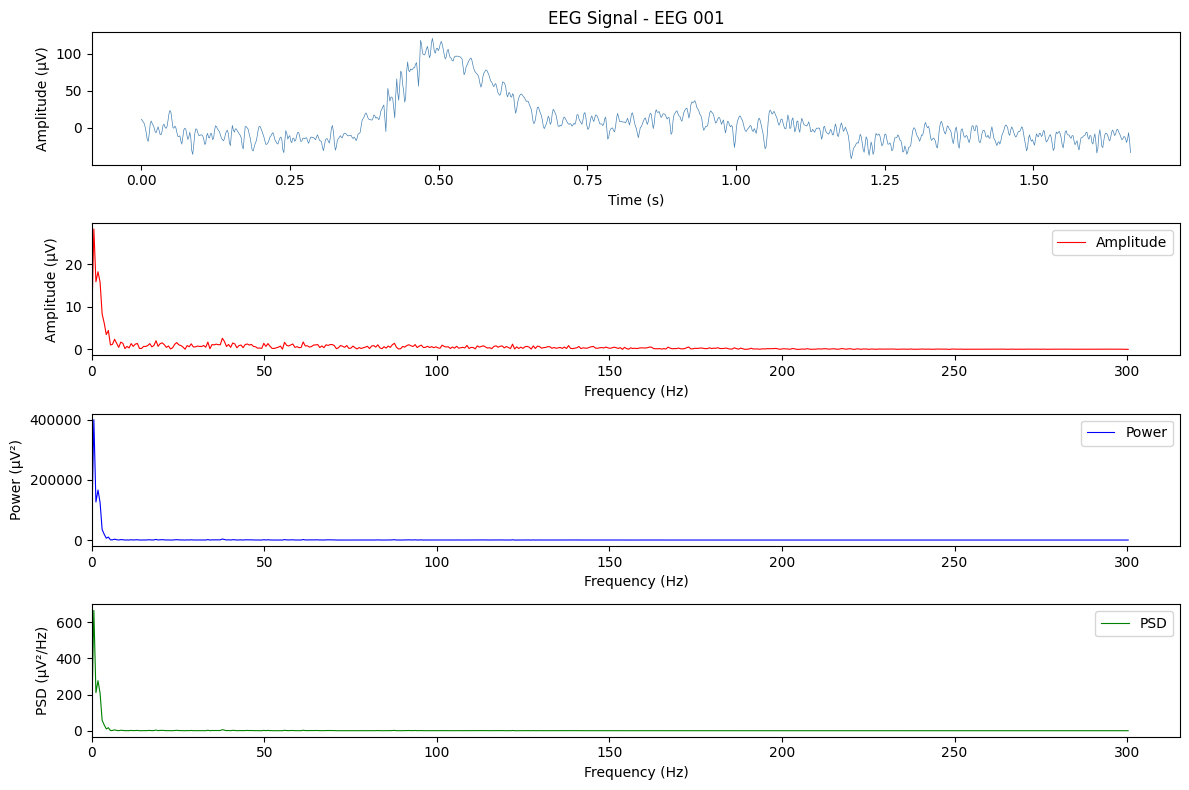

In [9]:
# ---- 取一个通道的数据 ----
sfreq = raw_eeg.info['sfreq']
data, times = raw_eeg[0]  # 第一个通道，shape (channel, n_times)
signal = data[0]          # 转一维数组

N = 1000

# 取前 1000 个样本
signal = signal[:N] * 1e6  # 转 μV
times = times[:N]

# ---- 手动 FFT ----
fft_vals = np.fft.rfft(signal) # 单边 FFT，没有x2
fft_freq = np.fft.rfftfreq(N, d=1.0 / sfreq)


# 振幅谱
amplitude = np.abs(fft_vals) / n
if n % 2 == 0:
    amplitude[1:-1] *= 2
else:
    amplitude[1:] *= 2

# 功率谱(实际周期图)
power = np.abs(fft_vals) ** 2 / n   # 功率谱(实际周期图):采集时间越长，y轴值越大,单位是 μV²
if n % 2 == 0:
    power[1:-1] *= 2
else:
    power[1:] *= 2

# 功率谱密度
psd = (np.abs(fft_vals) ** 2) / (sfreq * n)
if n % 2 == 0:
    psd[1:-1] *= 2
else:
    psd[1:] *= 2


# ---- 绘图 ----
fig, axes = plt.subplots(4, 1, figsize=(12, 8))

# 时域信号
axes[0].plot(times, signal, linewidth=0.5, color='steelblue')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].set_title(f'EEG Signal - {raw_eeg.ch_names[0]}')

axes[1].plot(fft_freq, amplitude, linewidth=0.8, color='r', label='Amplitude')
axes[1].legend()
axes[1].set_xlim(0)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude (μV)')


axes[2].plot(fft_freq, power, linewidth=0.8, color='b')
axes[2].legend(['Power'])
axes[2].set_xlim(0)
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Power (μV²)')


# psd 图
axes[3].plot(fft_freq, psd, linewidth=0.8, color='green')
axes[3].legend(['PSD'])
axes[3].set_xlim(0)
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_ylabel('PSD (μV²/Hz)')


plt.tight_layout()
plt.show()


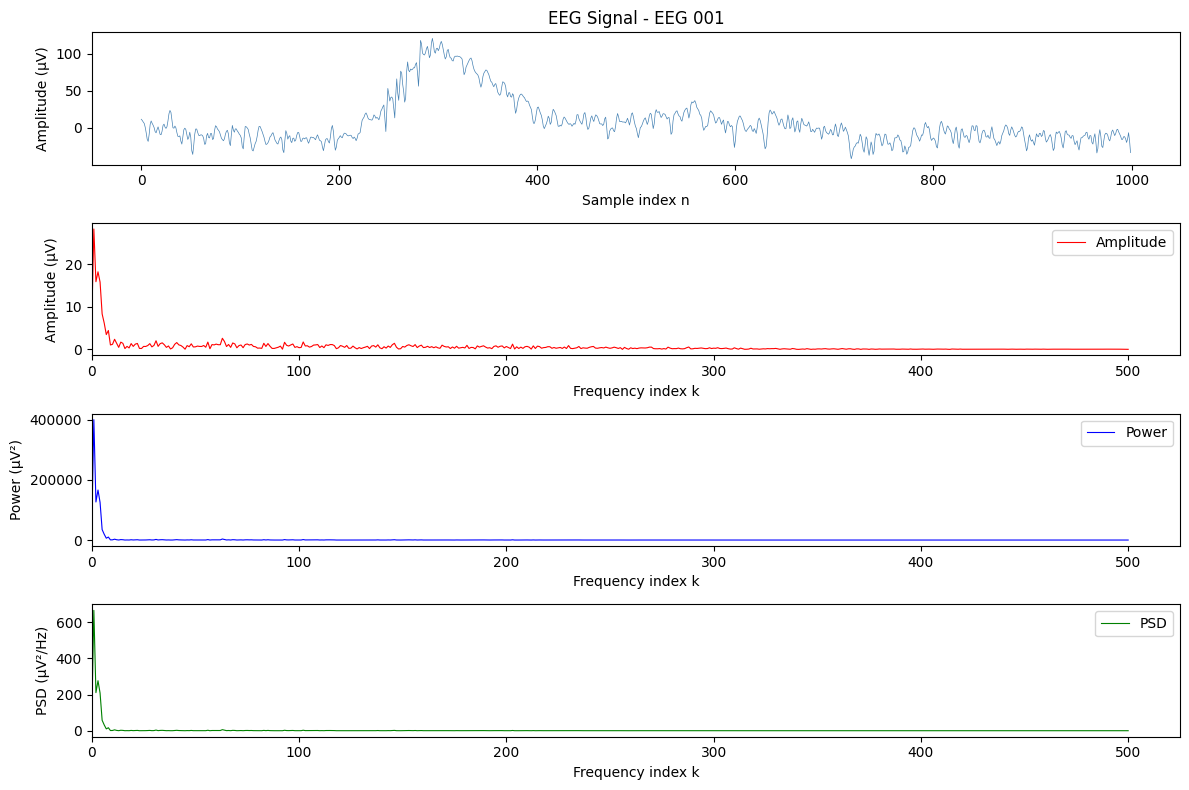

In [13]:
# ---- 取一个通道的数据 ----
sfreq = raw_eeg.info['sfreq']
data, times = raw_eeg[0]
signal = data[0]

N = 1000

signal = signal[:N] * 1e6  # 转 μV
times = times[:N]

# ---- 手动 FFT ----
fft_vals = np.fft.rfft(signal)
fft_freq = np.fft.rfftfreq(N, d=1.0 / sfreq)

# 振幅谱
n = N
amplitude = np.abs(fft_vals) / n
if n % 2 == 0:
    amplitude[1:-1] *= 2
else:
    amplitude[1:] *= 2

# 功率谱
power = np.abs(fft_vals) ** 2 / n
if n % 2 == 0:
    power[1:-1] *= 2
else:
    power[1:] *= 2

# 功率谱密度
psd = (np.abs(fft_vals) ** 2) / n / sfreq
if n % 2 == 0:
    psd[1:-1] *= 2
else:
    psd[1:] *= 2

# ---- 离散索引 ----
n_time = N                  # 时域样本数: 0, 1, ..., N-1
n_freq = len(fft_vals)      # 频域样本数: N//2 + 1, 即 0, 1, ..., N//2

k_time = np.arange(n_time)
k_freq = np.arange(n_freq)

# ---- 绘图 ----
fig, axes = plt.subplots(4, 1, figsize=(12, 8))

# 时域信号 — x 轴: 样本序号 n
axes[0].plot(k_time, signal, linewidth=0.5, color='steelblue')
axes[0].set_xlabel('Sample index n')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].set_title(f'EEG Signal - {raw_eeg.ch_names[0]}')

# 振幅谱 — x 轴: 频率序号 k
axes[1].plot(k_freq, amplitude, linewidth=0.8, color='r', label='Amplitude')
axes[1].legend()
axes[1].set_xlim(0)
axes[1].set_xlabel('Frequency index k')
axes[1].set_ylabel('Amplitude (μV)')

# 功率谱 — x 轴: 频率序号 k
axes[2].plot(k_freq, power, linewidth=0.8, color='b', label='Power')
axes[2].legend()
axes[2].set_xlim(0)
axes[2].set_xlabel('Frequency index k')
axes[2].set_ylabel('Power (μV²)')

# PSD — x 轴: 频率序号 k
axes[3].plot(k_freq, psd, linewidth=0.8, color='green', label='PSD')
axes[3].legend()
axes[3].set_xlim(0)
axes[3].set_xlabel('Frequency index k')
axes[3].set_ylabel('PSD (μV²/Hz)')

plt.tight_layout()
plt.show()


三个公式**全部正确**，单边谱的 ×2 处理也无误。下面逐一说明。

---

## 1. 振幅谱 ✓

$$A[k] = \frac{2\,|X[k]|}{n} \quad (k \neq 0,\; k \neq n/2)$$

验证：纯余弦 $x[j]=A\cos(2\pi f_0 j/f_s)$，DFT 峰值 $|X[k_0]|\approx An/2$，代入得 $A[k_0]=2\cdot(An/2)/n = A$，正好恢复原始振幅。

---

## 2. 功率谱（实际周期图）✓

$$P[k] = \frac{|X[k]|^2}{n}, \quad \text{非DC/非Nyquist 乘2}$$

这是标准的**原始周期图**（raw periodogram），定义来自 Oppenheim & Schafer：

$$\hat{P}[k] = \frac{1}{N}|X[k]|^2$$

**性质**：对所有频率求和后等于信号的**总能量**：

$$\sum_k P[k] = \frac{1}{n}\sum_{k=0}^{n-1}|X[k]|^2 \stackrel{\text{Parseval}}{=} \sum_{j=0}^{n-1}|x[j]|^2$$

所以确实采集时间越长（$n$ 越大），$y$ 轴值越大——这是原始周期图的固有特性，注释描述准确。

> **与 scipy 的差异**：scipy 的 `periodogram(x, fs, scaling='spectrum')` 返回的是 $2|X[k]|^2/n^2$，比你的公式多除一个 $n$，总和等于**平均功率**而非总能量。两者都是合法约定，只是归一化不同。

---

## 3. 功率谱密度（PSD）✓

$$S[k] = \frac{|X[k]|^2}{f_s \cdot n}, \quad \text{非DC/非Nyquist 乘2}$$

**验证**：PSD 对频率积分应等于信号的**平均功率**：

$$\sum_k S[k]\cdot\Delta f = \sum_k \frac{|X[k]|^2}{f_s \cdot n}\cdot\frac{f_s}{n} = \frac{1}{n^2}\sum_{k=0}^{n-1}|X[k]|^2 \stackrel{\text{Parseval}}{=} \frac{1}{n}\sum_{j=0}^{n-1}|x[j]|^2$$

单位：$\mu\text{V}^2 / \text{Hz}$，正确。与 scipy 的 `scaling='density'` 结果一致。

---

## 三者关系

```
振幅谱 A[k] = 2|X[k]|/n           单位: μV

功率谱 P[k] = |X[k]|²/n           单位: μV²
         ↓
PSD    S[k] = P[k] / f_s          单位: μV²/Hz
```

即 **PSD = 功率谱 / 采样率**，等价于 **PSD = |X|² / (f_s · n)**，三者自洽。

---

## 单边谱 ×2 处理小结

| 条件 | DC (k=0) | 中间频率 | Nyquist (k=n/2) |
|------|----------|----------|-----------------|
| n 偶 | ×1 | ×2 | ×1 |
| n 奇 | ×1 | ×2 | 不存在 |

你的 `if n % 2 == 0: [1:-1]` 和 `else: [1:]` 完全对应这个表，没有问题。

对，**PSD = power / sfreq**，完全等价。

$$\underbrace{\frac{|X[k]|^2}{f_s \cdot n}}_{\text{psd}} = \underbrace{\frac{|X[k]|^2}{n}}_{\text{power}} \div f_s$$

所以代码里可以简化为：

```python
psd = power / sfreq
```

不用再单独算一遍。